In [1]:
from inference_funcs import load_bit_phoneme_model, evaluate_model, decode_outputs
from dataset import getDatasetLoaders
device = 'cuda'

/home3/ebrahim2/miniconda3/envs/speech-bci/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
bit_phoneme_filepath = "/data/willett_data/outputs/time_masked_transfomer_characters_phonemes_80ms_seed_0/"
model, args = load_bit_phoneme_model(bit_phoneme_filepath)
model = model.to(device)

/home3/ebrahim2/miniconda3/envs/speech-bci/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [3]:
data_file = args['datasetPath']
trainLoaders, testLoaders, loadedData = getDatasetLoaders(
        data_file, 8, None, 
        False
    )

In [4]:
outputs, cer, per_day_cer, cer2, per_day_cer2 = evaluate_model(model, loadedData, args, partition='test', device='cuda')


/home3/ebrahim2/testing/transformers_with_dietcorp/src/neural_decoder/augmentations.py:170: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at ../aten/src/ATen/native/Convolution.cpp:895.)
  return self.conv(input, weight=self.weight, groups=self.groups, padding="same")


CER DAY 0: 0.373233
CER2 DAY 0: 0.354586
CER DAY 1: 0.288823
CER2 DAY 1: 0.275862
CER DAY 2: 0.255659
CER2 DAY 2: 0.238019
CER DAY 3: 0.275168
CER2 DAY 3: 0.254317
CER DAY 4: 0.152788
CER2 DAY 4: 0.124664
CER DAY 5: 0.110843
CER2 DAY 5: 0.099812
CER DAY 6: 0.135662
CER2 DAY 6: 0.116367
CER DAY 7: 0.171516
CER2 DAY 7: 0.152406
CER DAY 8: 0.170501
CER2 DAY 8: 0.142629
CER DAY 9: 0.179943
CER2 DAY 9: 0.178333
CER DAY 10: 0.161169
CER2 DAY 10: 0.143482
CER DAY 11: 0.190287
CER2 DAY 11: 0.191176
CER DAY 12: 0.160377
CER2 DAY 12: 0.139405
CER DAY 13: 0.144928
CER2 DAY 13: 0.134768
CER DAY 14: 0.109924
CER2 DAY 14: 0.100803
CER DAY 15: 0.119756
CER2 DAY 15: 0.105596
CER DAY 16: 0.139493
CER2 DAY 16: 0.114286
CER DAY 17: 0.168908
CER2 DAY 17: 0.144126
CER DAY 18: 0.124535
CER2 DAY 18: 0.108647
CER DAY 19: 0.126476
CER2 DAY 19: 0.109576
CER DAY 20: 0.106255
CER2 DAY 20: 0.100503
CER DAY 21: 0.143902
CER2 DAY 21: 0.127460
CER DAY 22: 0.130709
CER2 DAY 22: 0.126969
CER DAY 23: 0.167993
CER2 DAY 2

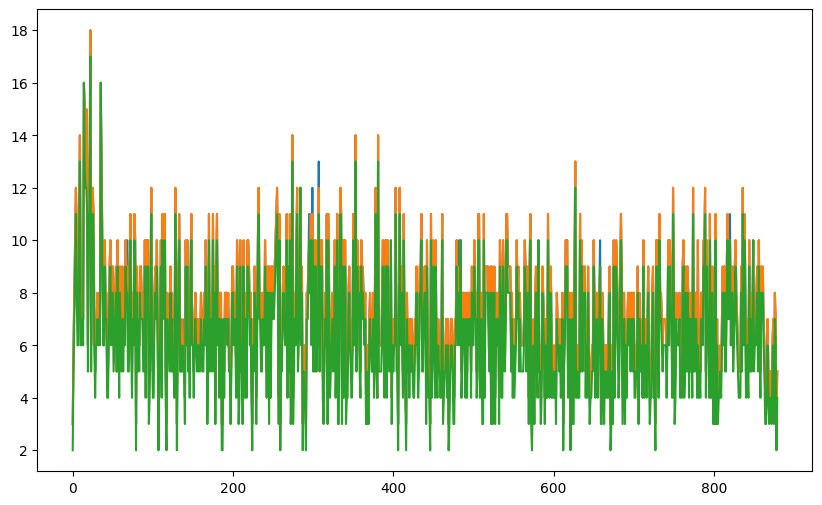

In [16]:
phonemes, chars, gt = decode_outputs(outputs, 880)
num_words_phonemes = [len(i.split(' ')) for i in phonemes]
num_words_chars = [len(i.split(' ')) for i in chars]
num_words_gt = [len(i.split(' ')) for i in gt]

for np, nc, ng in zip(num_words_phonemes, num_words_chars, num_words_gt):
    print(np,nc,ng)


['DHEHAAKAHS REHAWNTAHD ',
 'EYCHS PAACHIH SEHVAHL HHAWND LIHAOF ',
 'SOW ROWLSZOW WIY MEYND IHN AHNVAESH KAHLZHAHN ',
 'KROY KAESAHM NIYDAHD BAEK GAHVZ TUW BIY AHMPEHTLIY AELAHNT ',
 'DHAH TUWTH VEYIYEY RIHGAAT TUW HHAHM WAHN RAYDER THUWTH FAY AWT ',
 'DHAET SIHNGIHNG MEHSPPOY WIHDH KAAZ BAH KWAYD RIYPERAY LIHSHAHN ',
 'BIHF FAOR DHERTHEY AEAEM RIHIY VEHR EHVER FERMIHL ',
 'RAYDAHFAO DUW SAHN HHAES POWP  ',
 'DHAH WERD MIYNZ IHT WOWNT BERL AHWEY HHAESAHLIY NAYTHIHNG EHS ',
 'WUHD AH BUWTH FEHDHER IHN AH MAENS HHAYT MEYK HHIHM AEPIY AOL DEY ',
 'HHIY CHAAK AHBAWT AAN THLAETIHK SGRUWGAYNZ YUW ',
 'BAAST JHYIHNG REYZ HHERLIY EHVERIY MAORNIHNNG ',
 'WIHDH DHIHS NOW LAOAHL KEHIHLD KAEN GROWL ',
 'PREHN TAABZ HHAEV AEN AHBIYT AEDIHD ',
 'AHND IHTS NAAT AH JHAAJH BAHT AH KIHS AHV DHAH PEYST HHER MIYN DHAH DIHIHSIHZHAHN ',
 'WIY SIYNDZ TUW BIY WERTHIHNG DHAH PRERPCHUW LEHEYSHAHN IHSPLOWZHAHZ REHT IHN AOR WOWN BEYKGERNDZ ',
 'SAHMBZ SHIHPRT MEHZHERZ AHND AOLSOW SHUHD IHNTUWHHAY MUWV FAOR DHAH 